In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import sent_tokenize

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
from transformers import logging
logging.set_verbosity_error()


#nltk.download("punkt")
#nltk.download("punkt_tab")

#### Load the dataset

In [3]:
DOCS_DIR = Path(r"ebm_nlp_2_00\documents")

# Read only .txt files
text_files = sorted(DOCS_DIR.glob("*.txt"))

print(f"Number of .text files found: {len(text_files)}")
print("First 5 files:")
for f in text_files[:5]:
    print(f.name)

Number of .text files found: 4993
First 5 files:
10036953.txt
10037531.txt
10052279.txt
10070173.txt
10071998.txt


#### Empty sentences were removed to avoid introducing noise and invalid inputs into the embedding and clustering process

In [4]:
def split_into_sentences_raw(text: str):
    sentences = sent_tokenize(text)
    sentences = [s for s in sentences if s.strip() != ""]
    return sentences

#### Sentence Extraction

In [5]:
rows = []
for file_path in text_files:
    pmid = file_path.stem
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    sentences = split_into_sentences_raw(text)
    for sent_id, sent in enumerate(sentences):
        rows.append({
            "pmid": pmid,
            "sentence_id": sent_id,
            "sentence": sent
        })
        
df_work = pd.DataFrame(rows)
print(f"Total number of sentences: {len(df_work)}")
#display(df_work.head(10))

print(df_work)

Total number of sentences: 53544
           pmid  sentence_id  \
0      10036953            0   
1      10036953            1   
2      10036953            2   
3      10036953            3   
4      10036953            4   
...         ...          ...   
53539   9989713           10   
53540   9989713           11   
53541   9989713           12   
53542   9989713           13   
53543   9989713           14   

                                                sentence  
0      [Triple therapy regimens involving H2 blockade...  
1      Comparison of ranitidine and lansoprazole in s...  
2      To evaluate the efficacy and safety of two 1-w...  
3      The drug combination and administration period...  
4      The ranitidine group received RNT 300 mg, CAM ...  
...                                                  ...  
53539  FINDINGS 23 patients in the AT group and four ...  
53540  The subjective global assessments of the effec...  
53541  A per-protocol analysis did not show appreci

### Sentence Embedding

Sentences were encoded into dense vector representations using a pre-trained transformer model.  
These embeddings are used for downstream clustering.

In [6]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
# model_name = "sentence-transformers/all-mpnet-base-v2"
embedder = SentenceTransformer(model_name)

sentences = df_work["sentence"].tolist()
embeddings = embedder.encode(
    sentences,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/837 [00:00<?, ?it/s]

embeddings shape: (53544, 384)


### K-means Clustering
K-means clustering was applied to the sentence embeddings with k=3. We set the number of clusters to 4 to roughly mirror the four target schema fields: population, intervention, and outcome.

In [47]:
n_cluster_dict = {}

for n in range(3, 9):
    kmeans = KMeans(
        n_clusters=n,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(embeddings)
    n_cluster_dict[n] = cluster_labels

    print(pd.Series(cluster_labels).value_counts().sort_index())

0    19958
1    13480
2    20106
Name: count, dtype: int64
0    14701
1    12743
2    13763
3    12337
Name: count, dtype: int64
0     5877
1    12692
2     9244
3    13190
4    12541
Name: count, dtype: int64
0     8381
1     6347
2     5108
3    11570
4    10547
5    11591
Name: count, dtype: int64
0     8290
1     9882
2     2495
3     9947
4     6066
5     4964
6    11900
Name: count, dtype: int64
0    7427
1    7595
2    2307
3    9462
4    6212
5    8415
6    3505
7    8621
Name: count, dtype: int64


### Hierarchical clustering (HAC)
Hierarchical clustering was applied using cosine distance.  
Cluster sizes were examined to assess the distribution.

In [ ]:
hac = AgglomerativeClustering(
    n_clusters=3,
    metric='cosine',
    linkage='average'
)

cluster_labels = hac.fit_predict(embeddings)
df_work["cluster_hac"] = cluster_labels

print(df_work["cluster_hac"].value_counts().sort_index())

### Clustering Evaluation and Results
Both K-means (0.0236) and HAC (0.0385) achieved very low silhouette scores, indicating weak cluster separation.  
Both K-means and HAC achieved very low silhouette scores, indicating weak cluster separation in the embedding space. This suggests that sentence-level embeddings do not form strongly separated natural groups. Therefore, clustering is more suitable as a preliminary exploratory analysis than as direct evidence that sentences align cleanly with schema fields.

In [8]:
score_kmeans = silhouette_score(embeddings, df_work["cluster"])
#score_hac = silhouette_score(embeddings, df_work["cluster_hac"])

print("KMeans:", score_kmeans)
#print("HAC:", score_hac)

# 14:06 minutes to run

KMeans: 0.02508685179054737


In [48]:
for n, cluster_labels in n_cluster_dict.items():
    score_kmeans = silhouette_score(embeddings, cluster_labels)
    print(f"KMeans silhouette score when n={n}: {score_kmeans}")

KMeans silhouette score when n=3: 0.02508685179054737
KMeans silhouette score when n=4: 0.023531153798103333
KMeans silhouette score when n=5: 0.023414017632603645
KMeans silhouette score when n=6: 0.02369847521185875
KMeans silhouette score when n=7: 0.024470122531056404
KMeans silhouette score when n=8: 0.02395460568368435


### Visualization

In [9]:
def plot_clusters_pca(embeddings, labels, title="Cluster visualization (PCA)"):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(embeddings)

    df_plot = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "cluster": labels.astype(str)
    })

    plt.figure(figsize=(10, 8))

    for c in sorted(df_plot["cluster"].unique()):
        sub = df_plot[df_plot["cluster"] == c]
        plt.scatter(sub["x"], sub["y"], alpha=0.6, s=18, label=f"Cluster {c}")

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

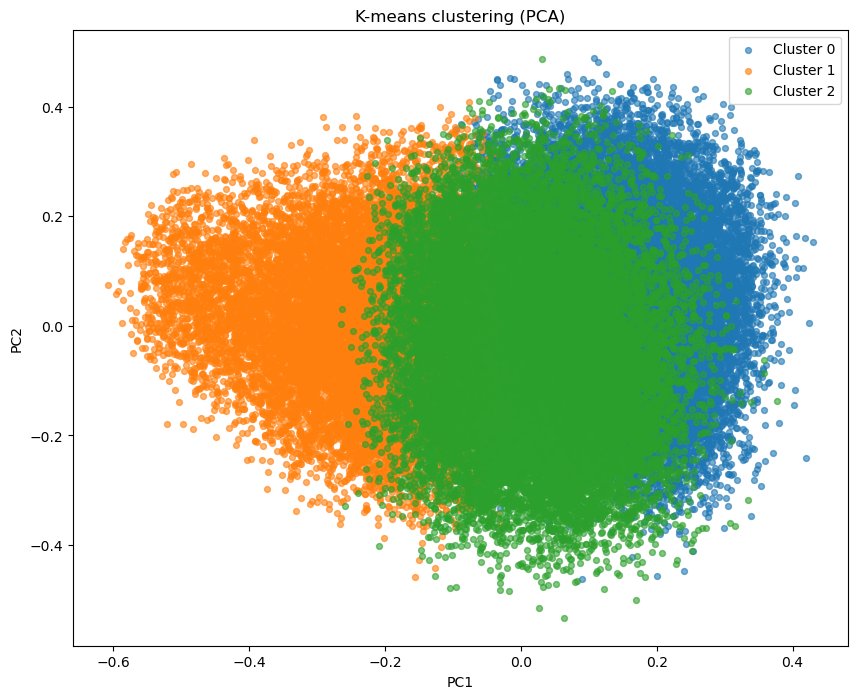

In [10]:
plot_clusters_pca(
    embeddings,
    df_work["cluster"],
    title="K-means clustering (PCA)"
)

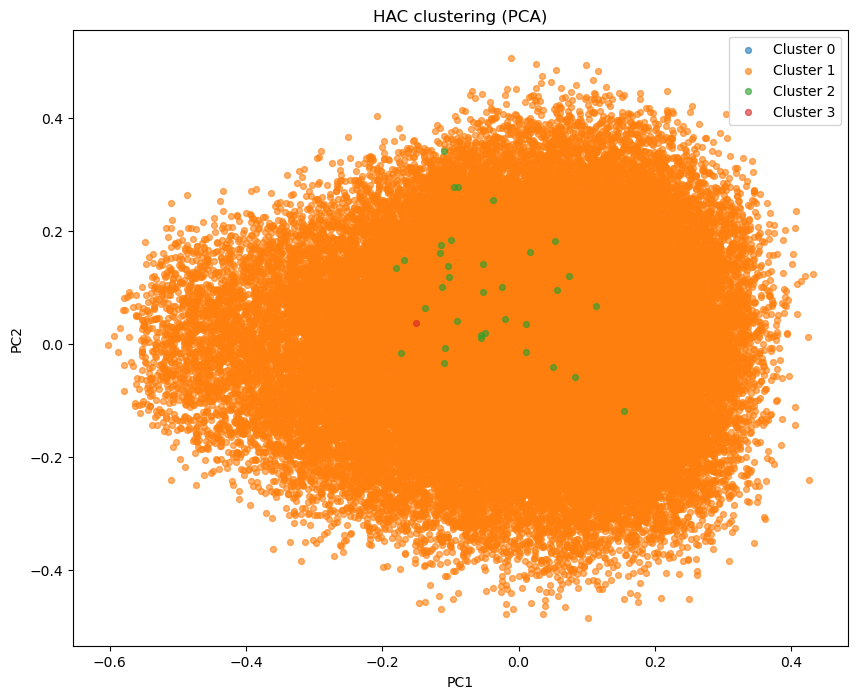

In [48]:
plot_clusters_pca(
    embeddings,
    df_work["cluster_hac"],
    title="HAC clustering (PCA)"
)

In [73]:
def inspect_cluster_content(
    df,
    label_col,
    text_col="sentence",
    n_examples=8,
    random_state=42
):
    print(f"\n{'='*80}")
    print(f"Inspecting clusters for: {label_col}")
    print(f"{'='*80}")

    for cid in sorted(df[label_col].unique()):
        sub = df[df[label_col] == cid].copy()
        print(f"\n--- Cluster {cid} | size = {len(sub)} ---")

        # Top TF-IDF terms for quick interpretation
        vec = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            max_features=3000
        )
        X = vec.fit_transform(sub[text_col])
        scores = np.asarray(X.mean(axis=0)).ravel()
        terms = vec.get_feature_names_out()
        top_idx = scores.argsort()[::-1][:10]
        top_terms = [terms[i] for i in top_idx]

        print("Top terms:", ", ".join(top_terms))

        # Show example sentences
        examples = (
            sub[text_col]
            .drop_duplicates()
            .sample(n=min(n_examples, sub[text_col].nunique()), random_state=random_state)
            .tolist()
        )

        print("Example sentences:")
        for i, sent in enumerate(examples, 1):
            print(f"{i}. {sent}")

### Results and Analysis of K-Means
Inspection of the K-means clusters indicated that the sentence groups did not align clearly with the target schema fields. Instead of separating population, intervention, and outcome information into distinct clusters, the results showed substantial mixing across fields. For instance, Cluster 0 contained a population sentence (“152 children were recruited”), an outcome sentence (“The primary outcome measure was significant improvement...”), and an intervention sentence (“The training intervention consisted of 6 supervised training sessions...” ). Cluster 1 showed a weak treatment-related tendency, with terms such as mg, placebo, dose, and treatment, but it still mixed intervention-related content with patient descriptions and background information. Cluster 3 was more strongly associated with result and comparison language, including terms such as significant, vs, and differences, yet it also contained other trial-related content rather than a pure outcome field. These findings suggest that K-means captures only weak thematic structure in the sentence embeddings and does not provide clusters that correspond cleanly to the predefined schema fields. As a result, clustering is more useful as an exploratory step than as a reliable extraction strategy.

In [75]:
# Inspect K-means clusters
inspect_cluster_content(df_work, label_col="cluster")


Inspecting clusters for: cluster

--- Cluster 0 | size = 11798 ---
Top terms: study, children, group, intervention, trial, autism, randomized, treatment, results, controlled
Example sentences:
1. Decision support tailored to psychological predictors of participation may increase screening.
2. Changes in motor cortex excitability associated with temporal repetitive transcranial magnetic stimulation in tinnitus: hints for cross-modal plasticity?
3. RESULTS 152 children were recruited.
4. Of the 104 inmates enrolled, 89 had at least 1 post-release study visit.
5. The primary outcome measure was significant improvement, defined as 50% improvement in pain and disability scores.
6. The training intervention consisted of 6 supervised training sessions over 7 weeks, targeting the improvement of the players' speed and power.
7. RESULTS Using an intent-to-treat approach, findings replicated earlier results with a very large effect size (d = 1.41) for the FF group and a large effect size (d = 1.

### Results and Analysis of HAC
Inspection of the HAC clusters showed that the resulting groups did not align with the target schema fields. Unlike K-means, HAC produced one overwhelmingly large cluster and several extremely small clusters, indicating poor separation in the embedding space. The large cluster mixed population, treatment, and outcome information, while the small clusters appeared to capture only isolated or unusual sentences rather than meaningful schema categories. For example, Cluster 1 included sentences about participant allocation, treatment comparability, and observed improvement, whereas Cluster 3 contained only a single sentence (“Free will and free won’t.”). Overall, HAC did not recover useful natural groupings for the predefined schema fields and was less informative than K-means in this preliminary analysis.

In [80]:
# Inspect HAC clusters
inspect_cluster_content(df_work, label_col="cluster_hac")


Inspecting clusters for: cluster_hac

--- Cluster 0 | size = 40 ---
Top terms: 3tc, data, kv, used, method, using, images, kv images, known, task
Example sentences:
1. In LPFSTs, a monaural, low-redundancy speech sample is distorted by using filtering to modify its frequency content.
2. The low-SF grating was a more effective adapter than the high-SF grating, incompatible with the FRF model.
3. The light source was a 150-W halogen lamp beam.
4. and a high-end five-panel projection system.
5. The procedure was repeated with NMI as cost function.
6. In this study the potential benefits and drawbacks of this new AR technology were evaluated.
7. METHODS We assigned 270 gaming (i.e.
8. An action observation/execution matching system might be one such mechanism.

--- Cluster 1 | size = 54638 ---
Top terms: patients, group, treatment, study, results, groups, trial, randomized, placebo, significant
Example sentences:
1. RESULTS The level of ACTH and CORT in plasma decreased and lymphocyte pro